In [ ]:
import marimo as mo

mo.md(
    """
    # Fixed Observation Noise

    Known per-sample measurement variances enter the exact training
    covariance as `K(X, X) + diag(noise_i)`. Latent predictions describe
    `p(f_test | y_train)`, while observed predictions require explicit
    test-point observation noise.

    The synthetic system below has a smooth latent function, but the
    observation-noise variance changes by input region: observations with
    `x <= 0` use variance `0.04`, while observations with `x > 0` use
    variance `0.10`. This lets the plots separate uncertainty from the
    latent function itself and uncertainty from noisy measurements.

    Notation used below: `D` is the training data, `x_*` is a test input,
    `f_* = f(x_*)` is the latent function value, `y_*` is a future noisy
    observation, and `sigma_obs^2(x_*)` is the known observation-noise
    variance at that test input.
    """
)

# Fixed Observation Noise

Known per-sample measurement variances enter the exact training
covariance as `K(X, X) + diag(noise_i)`. Latent predictions describe
`p(f_test | y_train)`, while observed predictions require explicit
test-point observation noise.

The synthetic system below has a smooth latent function, but the
observation-noise variance changes by input region: observations with
`x <= 0` use variance `0.04`, while observations with `x > 0` use
variance `0.10`. This lets the plots separate uncertainty from the
latent function itself and uncertainty from noisy measurements.

Notation used below: `D` is the training data, `x_*` is a test input,
`f_* = f(x_*)` is the latent function value, `y_*` is a future noisy
observation, and `sigma_obs^2(x_*)` is the known observation-noise
variance at that test input.

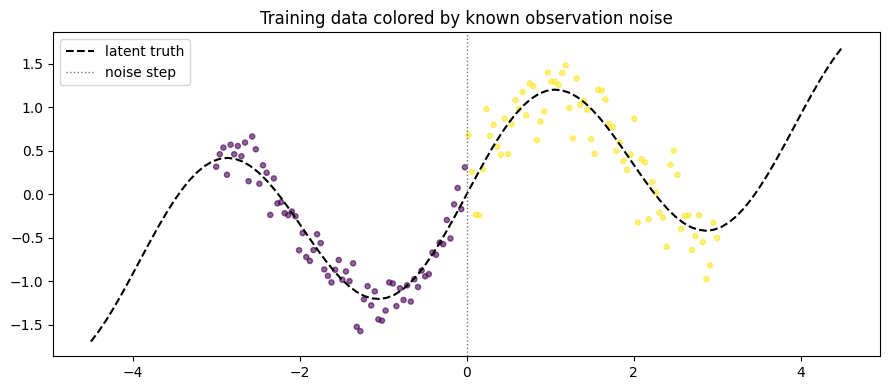

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(31)
X_train = np.linspace(-3.0, 3.0, 140, dtype=np.float32).reshape(-1, 1)
X_test = np.linspace(-4.5, 4.5, 100, dtype=np.float32).reshape(-1, 1)

def signal(X):
    return (np.sin(1.6 * X[:, 0]) + 0.2 * X[:, 0]).astype(np.float32)

def known_noise(X):
    return (0.04 + 0.06 * (X[:, 0] > 0)).astype(np.float32)

train_noise = known_noise(X_train)
test_noise = known_noise(X_test)
y_train = (signal(X_train) + rng.standard_normal(len(X_train)) * np.sqrt(train_noise)).astype(np.float32)
y_true = signal(X_test)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(X_train[:, 0], y_train, c=train_noise, cmap="viridis", s=14, alpha=0.6)
ax.plot(X_test[:, 0], y_true, "k--", label="latent truth")
ax.axvline(0.0, color="0.45", linestyle=":", linewidth=1.0, label="noise step")
ax.set_title("Training data colored by known observation noise")
ax.legend()
fig.tight_layout()
mo.mpl.interactive(fig)

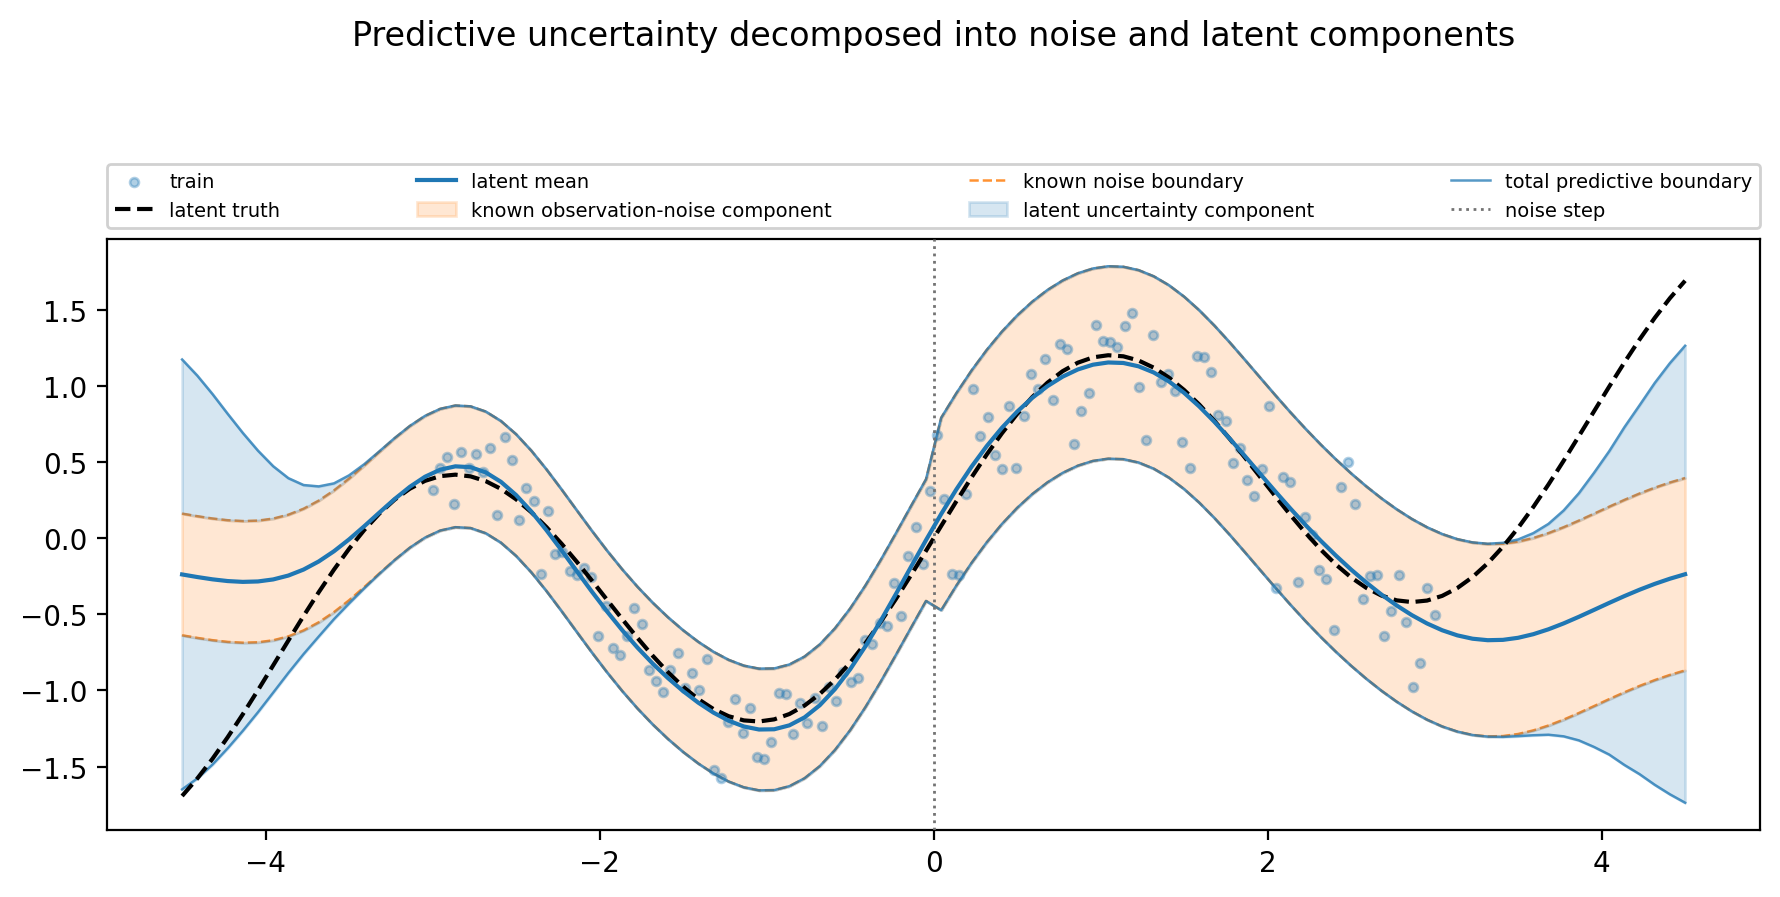

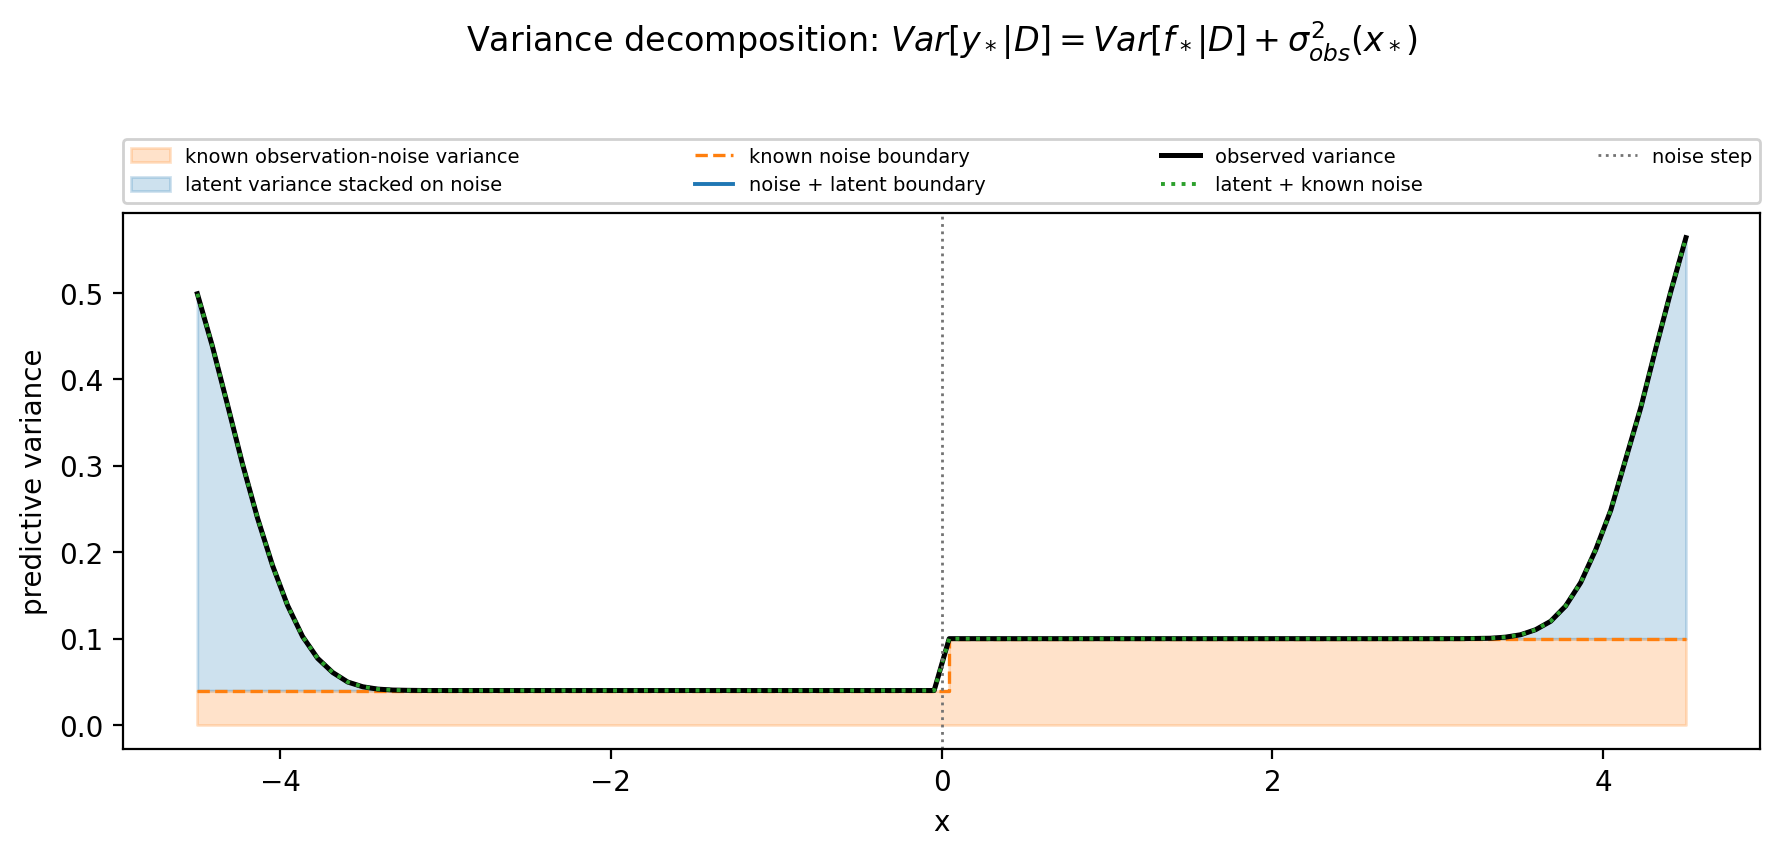

Quantity,Value
RMSE vs latent truth,0.5746
Final NLL,0.0785
Train noise range,0.040 to 0.100
Mean latent std,0.0886
Mean observed std,0.3073
Max variance decomposition error,0.00000000

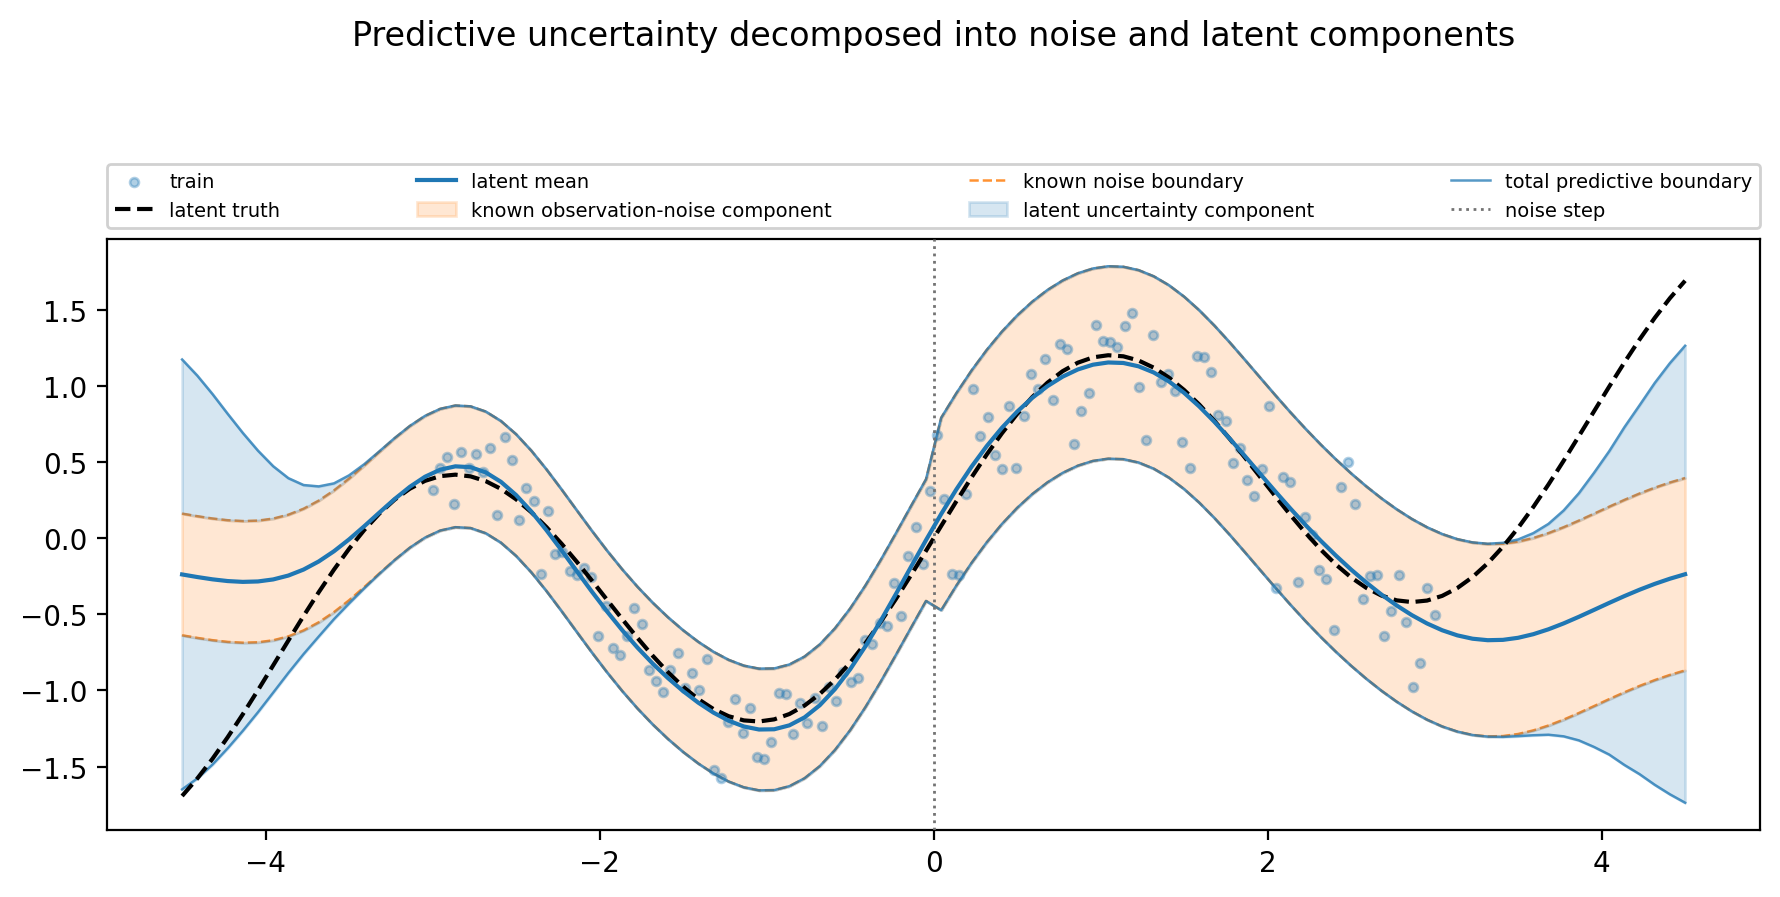
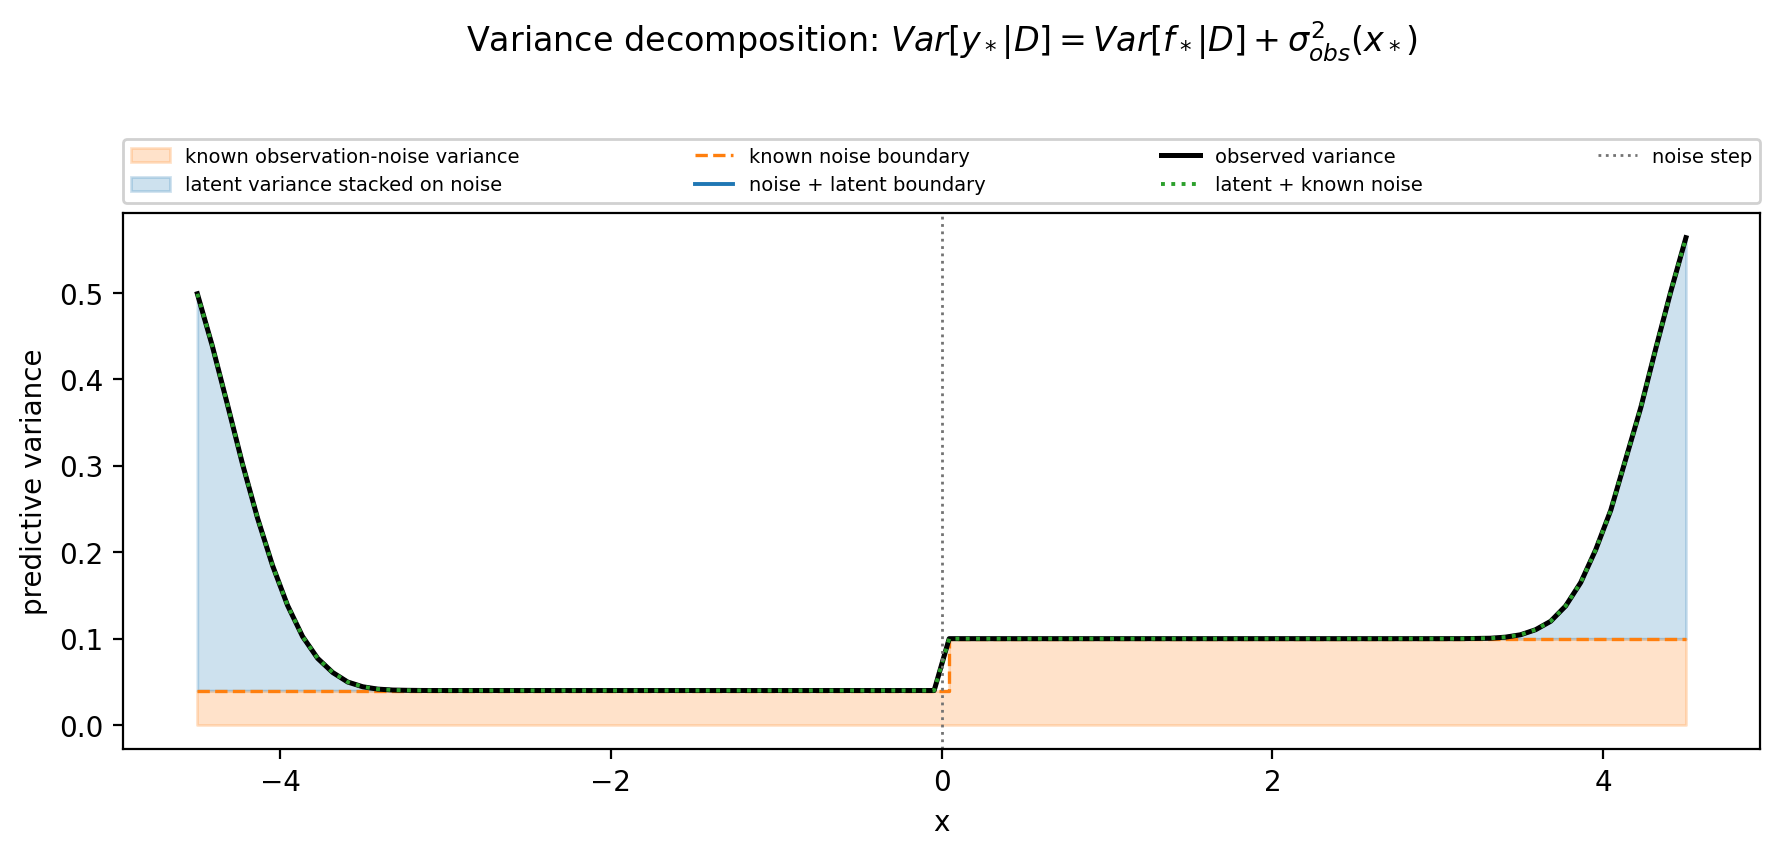

In [ ]:
from mojogp import RBF, SingleOutputGP

gp = SingleOutputGP(RBF(lengthscale=1.0, outputscale=1.0))
train_result = gp.fit(
    X_train,
    y_train,
    observation_noise=train_noise,
    learn_noise=False,
    max_iterations=20,
    learning_rate=0.035,
    method="materialized",
    progress=True,
)

latent = gp.predict_latent(X_test, variance_method="exact", progress=True)
observed = gp.predict_observed(
    X_test,
    observation_noise=test_noise,
    variance_method="exact",
    progress=True,
)
rmse = float(np.sqrt(np.mean((latent.mean - y_true) ** 2)))
observed_variance_from_sum = latent.variance + test_noise
observed_variance_gap = float(np.max(np.abs(observed.variance - observed_variance_from_sum)))
noise_interval_width = 2 * np.sqrt(test_noise)
observed_interval_width = 2 * observed.std

fig_pred, pred_ax = plt.subplots(figsize=(9, 4.6))
pred_ax.scatter(X_train[:, 0], y_train, s=10, alpha=0.35, label="train", zorder=3)
pred_ax.plot(X_test[:, 0], y_true, "k--", label="latent truth", zorder=4)
pred_ax.plot(X_test[:, 0], latent.mean, color="tab:blue", label="latent mean", zorder=5)
pred_ax.fill_between(
    X_test[:, 0],
    latent.mean - noise_interval_width,
    latent.mean + noise_interval_width,
    color="tab:orange",
    alpha=0.18,
    label="known observation-noise component",
    zorder=1,
)
pred_ax.plot(
    X_test[:, 0],
    latent.mean - noise_interval_width,
    color="tab:orange",
    linestyle="--",
    linewidth=0.9,
    alpha=0.85,
    zorder=2,
)
pred_ax.plot(
    X_test[:, 0],
    latent.mean + noise_interval_width,
    color="tab:orange",
    linestyle="--",
    linewidth=0.9,
    alpha=0.85,
    label="known noise boundary",
    zorder=2,
)
pred_ax.fill_between(
    X_test[:, 0],
    latent.mean + noise_interval_width,
    latent.mean + observed_interval_width,
    color="tab:blue",
    alpha=0.18,
    label="latent uncertainty component",
    zorder=2,
)
pred_ax.fill_between(
    X_test[:, 0],
    latent.mean - observed_interval_width,
    latent.mean - noise_interval_width,
    color="tab:blue",
    alpha=0.18,
    zorder=2,
)
pred_ax.plot(
    X_test[:, 0],
    latent.mean - observed_interval_width,
    color="tab:blue",
    linewidth=0.9,
    alpha=0.75,
    label="total predictive boundary",
    zorder=2,
)
pred_ax.plot(
    X_test[:, 0],
    latent.mean + observed_interval_width,
    color="tab:blue",
    linewidth=0.9,
    alpha=0.75,
    zorder=2,
)
pred_ax.set_title("Predictive uncertainty decomposed into noise and latent components", pad=70)
pred_ax.axvline(0.0, color="0.45", linestyle=":", linewidth=1.0, label="noise step", zorder=4)
pred_ax.legend(
    fontsize=7,
    loc="lower left",
    bbox_to_anchor=(0.0, 1.02, 1.0, 0.25),
    mode="expand",
    ncol=4,
    borderaxespad=0.0,
    framealpha=0.9,
)
fig_pred.tight_layout()

fig_var, var_ax = plt.subplots(figsize=(9, 4.4))
var_ax.fill_between(
    X_test[:, 0],
    0.0,
    test_noise,
    color="tab:orange",
    alpha=0.22,
    step="post",
    label="known observation-noise variance",
)
var_ax.fill_between(
    X_test[:, 0],
    test_noise,
    observed_variance_from_sum,
    color="tab:blue",
    alpha=0.22,
    label="latent variance stacked on noise",
)
var_ax.plot(
    X_test[:, 0],
    test_noise,
    color="tab:orange",
    linestyle="--",
    linewidth=1.2,
    drawstyle="steps-post",
    label="known noise boundary",
)
var_ax.plot(
    X_test[:, 0],
    test_noise + latent.variance,
    color="tab:blue",
    linewidth=1.4,
    label="noise + latent boundary",
)
var_ax.plot(
    X_test[:, 0],
    observed.variance,
    color="black",
    linewidth=1.8,
    label="observed variance",
)
var_ax.plot(
    X_test[:, 0],
    observed_variance_from_sum,
    color="tab:green",
    linestyle=":",
    linewidth=1.4,
    label="latent + known noise",
)
var_ax.axvline(0.0, color="0.45", linestyle=":", linewidth=1.0, label="noise step")
var_ax.set_title(
    r"Variance decomposition: $Var[y_* | D] = Var[f_* | D] + \sigma^2_{obs}(x_*)$",
    pad=58,
)
var_ax.set_xlabel("x")
var_ax.set_ylabel("predictive variance")
var_ax.legend(
    fontsize=7,
    loc="lower left",
    bbox_to_anchor=(0.0, 1.02, 1.0, 0.22),
    mode="expand",
    ncol=4,
    borderaxespad=0.0,
    framealpha=0.9,
)
fig_var.tight_layout()
mo.vstack(
    [
        mo.mpl.interactive(fig_pred),
        mo.mpl.interactive(fig_var),
        mo.md(
            f"""
            ## Fit Summary

            | Quantity | Value |
            |---|---:|
            | RMSE vs latent truth | {rmse:.4f} |
            | Final NLL | {train_result.nll:.4f} |
            | Train noise range | {float(train_noise.min()):.3f} to {float(train_noise.max()):.3f} |
            | Mean latent std | {float(np.mean(latent.std)):.4f} |
            | Mean observed std | {float(np.mean(observed.std)):.4f} |
            | Max variance decomposition error | {observed_variance_gap:.8f} |
            """
        ),
    ]
)